<a href="https://colab.research.google.com/github/kirthankulkarni-bit/assip-ML-stress-monitoring/blob/main/notebooks/02_data_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import pickle

# mount drive
drive.mount('/content/drive')

print("copying zip file from drive to local colab storage")
!cp "/content/drive/MyDrive/ASSIP/archive.zip" "/content/archive.zip"

# unzip it locally using the linux utility
print("unzipping the local file...")
!unzip -q "/content/archive.zip" -d "/content/wesad_data"

# path to the pickle file inside the unzipped folder
data_file_path = '/content/wesad_data/WESAD/S2/S2.pkl'

print("loading subject 2 data...")
with open(data_file_path, 'rb') as file:
    subject_data = pickle.load(file, encoding='latin1')

print("keys found in the file:", subject_data.keys())

Mounted at /content/drive
copying zip file from drive to local colab storage
unzipping the local file...
loading subject 2 data...
keys found in the file: dict_keys(['signal', 'label', 'subject'])


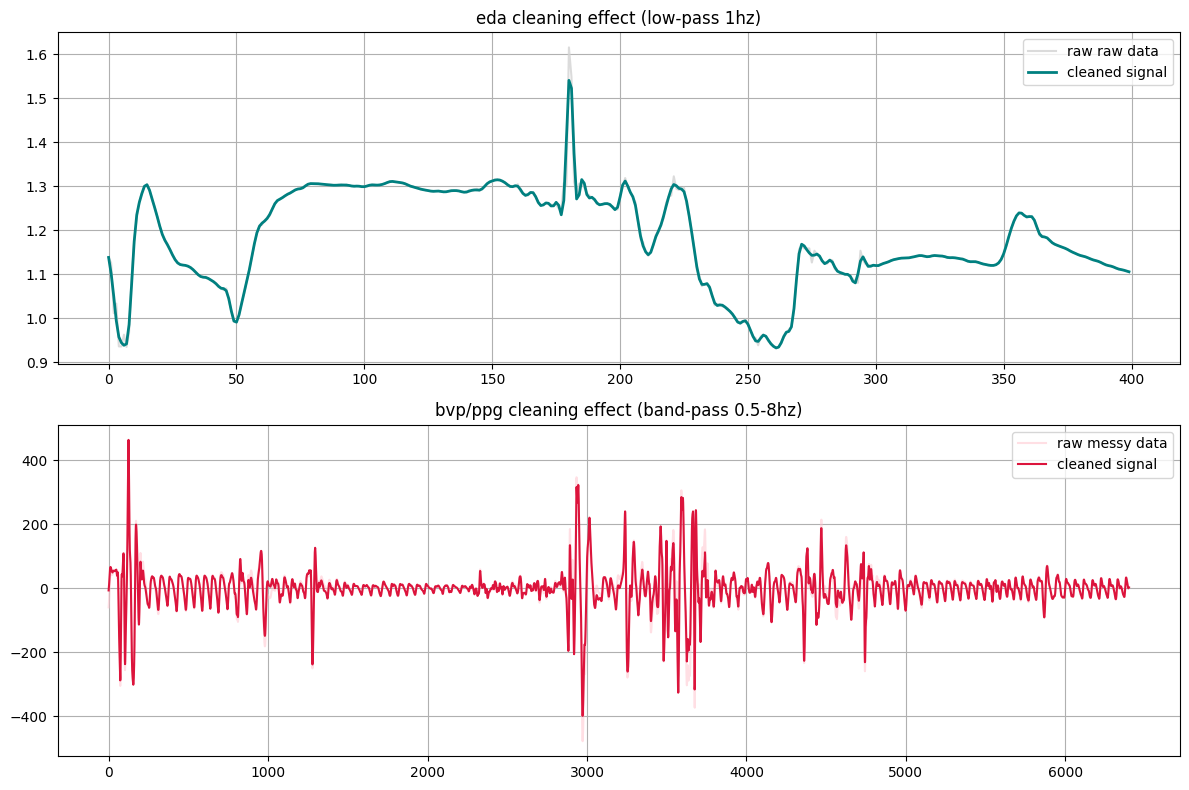

In [2]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def eda_lowpass_filter(data, cutoff=1.0, fs=4.0, order=4): # eda signal lowpass filtering (kills high freq noise above 1 hz)
  nyq = 0.5 * fs # nyquist freq is half of sampling rate
  cutoff_freq = cutoff / nyq
  b, a = butter(order, cutoff_freq, btype='low', analog=False) # building butterworth filter coefficients
  return filtfilt(b, a, data) # eliminates the phase shift caused by running time-series arrays through a butterworth fiter


def bvp_bandpass_filter(data, lowcut=0.5, highcut=8.0, fs=64.0, order=4): # bvp signal bandpass filtering to cut out breathing drift (low) and sensor static (high)
  nyq = 0.5 * fs
  low = lowcut / nyq
  high = highcut / nyq
  b, a = butter(order, [low, high], btype='band', analog=False)
  return filtfilt(b, a, data)

# run raw data throguh filters
raw_eda = subject_data['signal']['wrist']['EDA'].flatten()
raw_bvp = subject_data['signal']['wrist']['BVP'].flatten()

clean_eda = eda_lowpass_filter(raw_eda)
clean_bvp = bvp_bandpass_filter(raw_bvp)

# plot a 100-second window to see difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# build eda plot
ax1.plot(raw_eda[:400], label='raw raw data', color='lightgray', alpha=0.8)
ax1.plot(clean_eda[:400], label='cleaned signal', color='teal', linewidth=2)
ax1.set_title('eda cleaning effect (low-pass 1hz)')
ax1.legend()
ax1.grid(True)

# build bvp plot
ax2.plot(raw_bvp[:6400], label='raw messy data', color='pink', alpha=0.5)
ax2.plot(clean_bvp[:6400], label='cleaned signal', color='crimson', linewidth=1.5)
ax2.set_title('bvp/ppg cleaning effect (band-pass 0.5-8hz)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()